이미지 확인


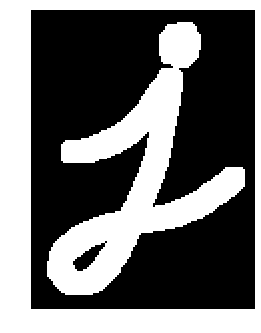

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('grasil.png', cv2.IMREAD_GRAYSCALE)

if img is not None:
    print("이미지 확인")
    cv2_imshow(img)
else:
    print("이미지를 찾을 수 없습니다.")

원본, 팽창, 침식 결과비교


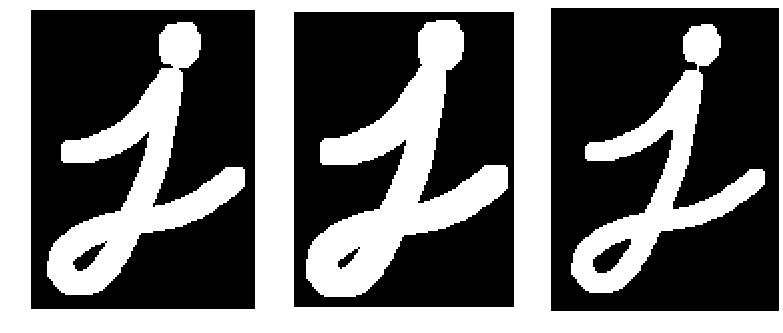

In [2]:
# 5x5 크기 커널 만들기
kernel = np.ones((5, 5), np.uint8)

# Dilation 적용. opencv가 자동으로 인터널패딩을 해주고있기 때문에 실제로는 패딩이 적용됨
dilation_result = cv2.dilate(img, kernel, iterations=1)

# Erosion 적용
erosion_result = cv2.erode(img, kernel, iterations=1)

# 결과 비교
print("원본, 팽창, 침식 결과비교")
combined = np.hstack((img, dilation_result, erosion_result))
cv2_imshow(combined)

원본, Opening 결과 비교


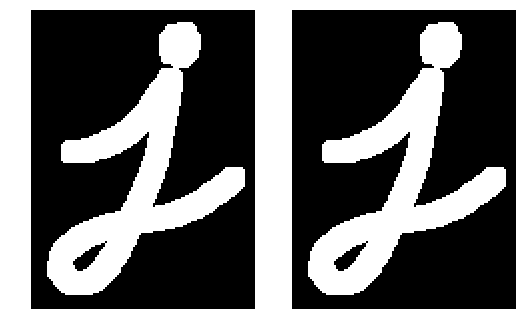

In [5]:
# Opening 적용 (침식 후 팽창)
# morphologyEx를 활용해 침식과 팽창을 묶어서 실
opening_result = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

# 결과 확인
print("원본, Opening 결과 비교")
opening_combined = np.hstack((img, opening_result))
cv2_imshow(opening_combined)

깎여나간 부분


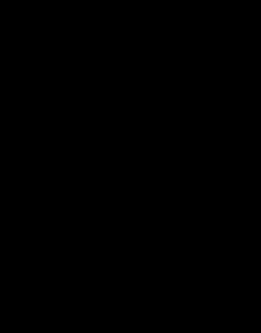

In [7]:
# 원본과 opening연산 후의 이미지 비교가 어려워서 확실한 차이를 위해 추가적으로 뺄셈연산을 넣어보았습니다.
# 결과적으로 아무것도 없었고, 커널보다 작은 노이즈가 없었기 때문에 삭제될 부분도 없었다는것을 확인하였습니다.

diff = cv2.absdiff(img, opening_result)
print("깎여나간 부분")
cv2_imshow(diff)

노이즈 추가 이후 opening으로 제거


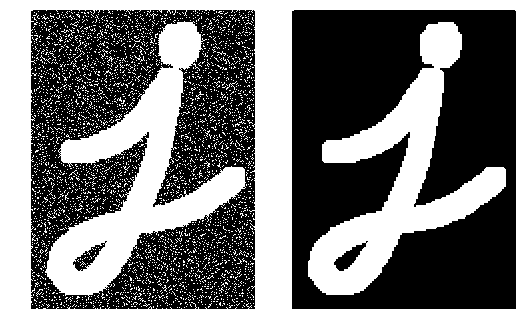

In [8]:
# 따라서 이미지에 노이즈를 추가하고 다시 opening을 통해 제거해보겠습니다.
noise = np.zeros(img.shape, np.uint8)
cv2.randn(noise, 0, 255) # 랜덤 노이즈 생성
noisy_img = cv2.add(img, (noise > 250).astype(np.uint8) * 255) # 흰 점으로 노이즈를 기존 사진에 add

# 노이즈 제거를 위해 다시 opening 적용
denoised_opening = cv2.morphologyEx(noisy_img, cv2.MORPH_OPEN, kernel)

print("노이즈 추가 이후 opening으로 제거")
cv2_imshow(np.hstack((noisy_img, denoised_opening)))

원본, Closing 결과비교


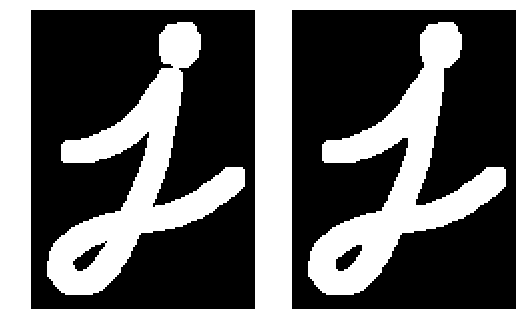

In [9]:
# closing 적용
# 이번 연산 결과또한 기존 이미지에 작은 구멍이나 손상이 없었기때문에 기존 이미지와 동일하게 출력.
closing_result = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

# 결과 확인
print("원본, Closing 결과비교")
closing_combined = np.hstack((img, closing_result))
cv2_imshow(closing_combined)

이미지 손상후 Closing 적용


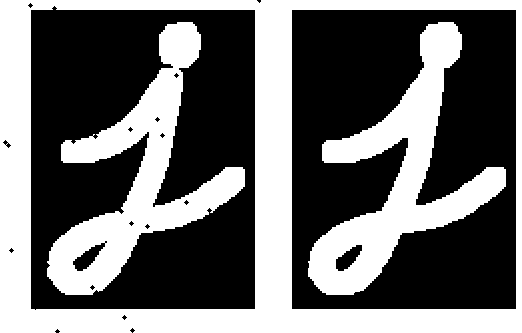

In [10]:
#이번에도 Closing의 적용을 보기위해 손상을 직접 추가해보고 다시 실행합니다
import random

# 원본 복사
hole_img = img.copy()
h, w = img.shape

# 이미지의 랜덤한 위치에 작은 구멍 생성
num_holes = 50
for _ in range(num_holes):
    rand_w = random.randint(0, w - 1)
    rand_h = random.randint(0, h - 1)
    cv2.circle(hole_img, (rand_w, rand_h), 2, (0), -1)

# 다시 Closing 적용
final_closing_kernel = np.ones((5, 5), np.uint8)
closed_result = cv2.morphologyEx(hole_img, cv2.MORPH_CLOSE, final_closing_kernel)

print(f"이미지 손상후 Closing 적용")
combined_final = np.hstack((hole_img, closed_result))
cv2_imshow(combined_final)